<a href="https://colab.research.google.com/github/TridentifyIshaan/BuildWithAI/blob/mainstream/ANN_model_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Loading the dataset

In [42]:
'''
Better to use try except, to know if the error is happening or not.
If the file is not in the directory, it will just exit the program.
'''
try:
    df = pd.read_csv('heart.csv')
except FileNotFoundError:
    print("Please upload the 'heart.csv' file to proceed.")
    exit()

# Data Cleaning

In [43]:
# Dropping rows with missing value
df_dropped = df.dropna()

# Print the number of rows before and after dropping
print(f"Number of rows before dropping: {len(df)}")
print(f"Number of rows after dropping: {len(df_dropped)}")

# To check how many rows got dropped if yes.
if len(df) == len(df_dropped):
    print("No rows were dropped.")
else:
    print(f"{len(df) - len(df_dropped)} rows were dropped.")

Number of rows before dropping: 1025
Number of rows after dropping: 1025
No rows were dropped.


# Viewing Clean Data

In [44]:
# Info of columns and data types
df_dropped.info()
print("\n")
# Statistical summary
print(df_dropped.describe())
print("\n")

# Table
print("\nCleaned data sample:\n")
print(df_dropped.head())
print("...")
print("...")
print("...")
print(df_dropped.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0000

# Preprocessing the Data

## Seperating the features & target variable

In [45]:
X = df.drop('target', axis=1)
y = df['target']

## Splitting data

In [46]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling data

In [47]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Building & operating the model

## Building the ANN Model

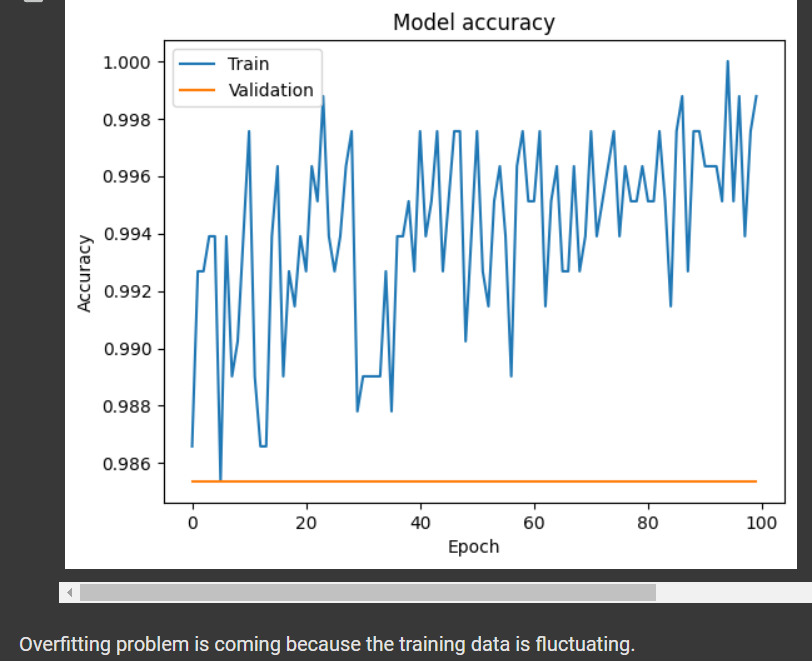

**Earlier a lot of fluctuation was happening which indicates overfitting of the training data, hence I introced kernel regularizers here, to reduce it.**

In [54]:
from tensorflow.keras.regularizers import l1, l2

# Build the ANN model, adding these kernel regularizers
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

## Compiling the model

In [55]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Training the model

In [56]:
# 100 epochs with batch size 32
'''
NOTE - Change the hardware accelerator to T4 GPU, because 100 epochs with
this much batch size will take a lot of time.
'''
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# The last time I used T4 GPU, it was not that fast
# I got the results in just 10 seconds

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6525 - loss: 1.6516
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8166 - loss: 1.2721
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8648 - loss: 1.0179
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8578 - loss: 0.8681
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8840 - loss: 0.7349
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8773 - loss: 0.6584
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8818 - loss: 0.5999
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8866 - loss: 0.5360
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8900 - loss: 0.5044
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8887 - loss: 0.4742
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8972 - loss: 0.4495
Epoch 12/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy

## Training the model with validation

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9645 - loss: 0.2071 - val_accuracy: 0.9366 - val_loss: 0.2463
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9636 - loss: 0.2041 - val_accuracy: 0.9317 - val_loss: 0.2436
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9602 - loss: 0.2018 - val_accuracy: 0.9171 - val_loss: 0.2553
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9755 - loss: 0.1926 - val_accuracy: 0.8878 - val_loss: 0.2571
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9650 - loss: 0.2046 - val_accuracy: 0.9463 - val_loss: 0.2413
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9709 - loss: 0.1997 - val_accuracy: 0.9366 - val_loss: 0.2416
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9548 - loss: 0.2098 - val_accuracy: 0.9317 - val_loss: 0.2441
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9638 - loss: 0.2045 - val_accuracy: 0.9268 - 

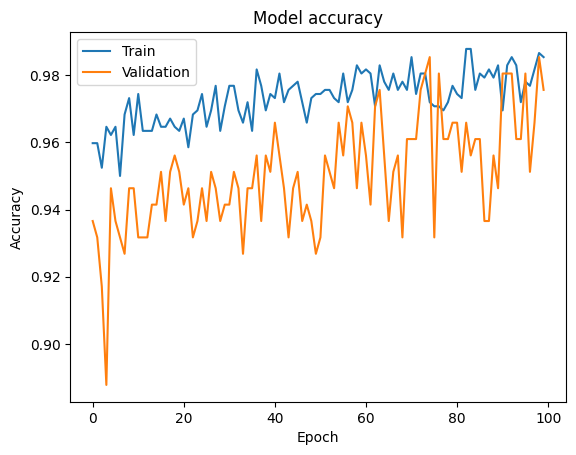

In [57]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**The fluctuations have been reduced than the previous graph of training data and the validated training data is now currently more closely following the train data, which is an indication of healthy learning rate.**

## Comparision

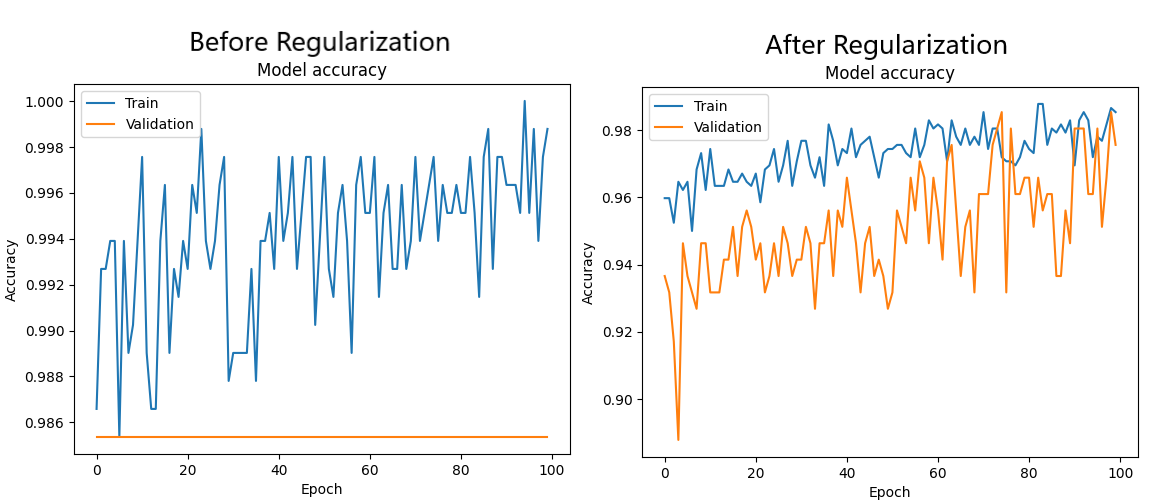

## Evaluating the model

In [58]:
# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


# Result / Output

In [59]:
print(f"Accuracy: {accuracy}\n")
print(f"Classification Report: \n {report}")

Accuracy: 0.975609756097561

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       102
           1       0.99      0.96      0.98       103

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205

